# Motion

*The drive as three verbs: a stepper and its ring, a servo and its sag, a sensorless speed loop with its observer held against the shaft sensor, that loop identified out of its own run, and the 5230SL with its propeller against the maker's thrust stand.*

**Abstract.** `device.motion` is the drive as three verbs over the link - `stepper`, `servo`, `velocity` - and `coaxial.control.loop` is the speed loop the third one runs, as blocks on a bus that close around a motor model without a board. This notebook drives all of it on the stand-in, whose rotor turns under the torque the dq solution makes and whose shaft sensor reads that same rotor, and on a board with the knob flipped. What it measures: the ring a held rotor carries after a 90 degree move, read every 2 ms and set against the load-angle spring's own arithmetic; the sag a 0.02 N.m load pulls into a servo hold and the correction that takes it back; a sensorless run to 600 rpm with the observer's error and the shaft's own speed logged every pass; the machine's R, Ld, Lq and lambda recovered from a run with and without a d-axis probe, each with its own error bar; and the 5230SL under an APC20x10E driven to the stand's top row at 37 V, read against the 22 rows Hobbywing measured. Headline: the sag lands within 0.02 degrees of the spring's arithmetic, the ring within a hertz of it; the observer's error is a fraction of an electrical degree and zero at constant speed; without the probe only lambda is trusted, and with it R is still 63 % high inside a 0.8 % error bar; the model runs out of voltage 1000 rpm short of the stand. What a reader takes to the bench: the stepper is open loop and the servo closes once per move, a trusted column is not a right one, and the inverter's 100 A is the limit before the motor's 112.5 A.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The stage, armed

Every verb needs the stage armed first, by `device.gates.on()` - the one place arming lives, and nothing in `coaxial.control.motion` is the second - and the drive on the `model` source, where the stand-in's rotor turns under the torque the dq solution makes and the shaft sensor reads that same rotor. `J` and `B` are the model's inertia and friction, named here because the spring's arithmetic below uses them; `Kt` is `1.5 P lambda` from the record the drive runs on.

In [3]:
import math
import time

drive = device.drive
drive.configure(source='model')
J, B = 2e-5, 1e-5
drive.model.configure(j=J, b=B, load=0.0)
stage = device.gates.on(bypass_sto=True, ignore_interlock=True)
params = drive.params()
poles = int(params['motor_pole_pairs'])
kt = 1.5 * poles * params['motor_lambda_uvs']
print('armed:', stage['pwm_enabled'])
print('%d pole pairs, lambda %.5f Wb, Kt = 1.5 P lambda = %.4f N.m/A; J %.0e kg.m^2, B %.0e N.m.s'
      % (poles, params['motor_lambda_uvs'], kt, J, B))

armed: True
7 pole pairs, lambda 0.00500 Wb, Kt = 1.5 P lambda = 0.0525 N.m/A; J 2e-05 kg.m^2, B 1e-05 N.m.s


## 3 The stepper: a move and its ring

HOLD holds a current vector at a commanded angle and the rotor is dragged along by the load-angle spring, `amps Kt sin(delta)`: a microstepper. Open loop, so an overload slips poles silently. `to()` slews the command at `deg_s` in quarter-degree writes, so the spring never spans more than a few degrees at once; `step()` is the classic vocabulary. The shaft is read every 2 ms through the ring: a held rotor rings at some 30 Hz, and a read every 20 ms drew that ring aliased into a slow sawtooth (FINDINGS, 2026-09-07). On a link the A1335 answers every 15 ms or so, so a trace this fine is the model's. The spring's own frequency is arithmetic on the record: `sqrt(Kt I P / J)`.

In [4]:
def trace(seconds, zero, every=0.002):
    """The shaft every `every` seconds, mechanical degrees from `zero`."""
    rows = []
    t0 = time.monotonic()
    while time.monotonic() - t0 < seconds:
        deg = device.angle.state()['degrees']
        rows.append((time.monotonic() - t0, (deg - zero + 180.0) % 360.0 - 180.0))
        time.sleep(every)
    return rows

with device.motion.stepper(amps=2.0, deg_s=90.0) as m:
    detent = device.angle.state()['degrees']
    print('detented: command at %.2f deg, shaft at %.2f' % (m.position, detent))
    m.to(90.0)
    ring = trace(0.6, detent)
    m.step(10)
    print('ten full steps of 1.8 deg: command at %.1f deg' % m.position)
ys = [r[1] for r in ring]
level = sum(ys) / len(ys)
crossings = sum(1 for a, b in zip(ys, ys[1:]) if (a - level) * (b - level) < 0)
ring_hz = crossings / 2.0 / ring[-1][0]
spring_hz = math.sqrt(kt * 2.0 * poles / J) / (2.0 * math.pi)
print('after the 90 deg move: shaft %.2f deg from the detent, ringing %.2f deg '
      'peak to peak at about %.0f Hz; the spring says %.1f Hz'
      % (level, max(ys) - min(ys), ring_hz, spring_hz))
print('%d reads in %.2f s = %.0f Hz' % (len(ring), ring[-1][0], len(ring) / ring[-1][0]))

detented: command at 0.00 deg, shaft at 0.00


ten full steps of 1.8 deg: command at 108.0 deg
after the 90 deg move: shaft 89.96 deg from the detent, ringing 0.09 deg peak to peak at about 30 Hz; the spring says 30.5 Hz
258 reads in 0.60 s = 431 Hz


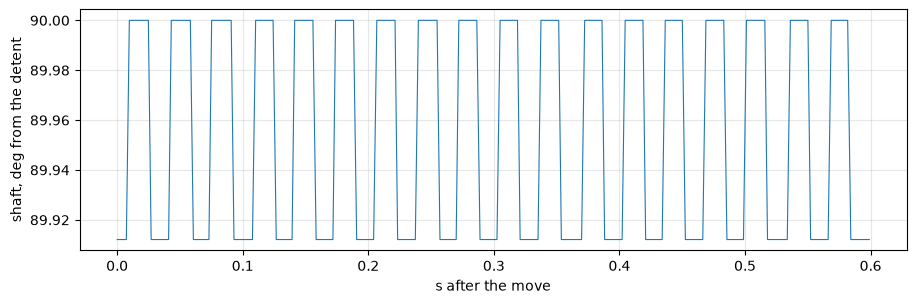

In [5]:
from coaxial.draw.figures import figure, show

fig, (panel,) = figure(rows=1)
panel.plot([r[0] for r in ring], ys, linewidth=0.8)
panel.set_xlabel('s after the move')
panel.set_ylabel('shaft, deg from the detent')
show(fig)

## 4 The servo: sag under load, corrected

The servo is the same move with the slip measured out: slew, let the ring die, read the shaft as a mean over its ring, correct what the load stole, until inside `tol`. A load on the model winds the spring, and the shaft sits where `amps Kt sin(delta)` balances it, so the sag is arithmetic on the record's Kt and the holding current before it is a measurement. The trace watches the shaft for a second after the load steps on - the spring settling under it, in place of a wait - and `to()` then corrects. `swing` is how far the shaft moved while the last measurement watched it, and `error` is target minus shaft from the last correction.

In [6]:
with device.motion.servo(amps=2.0, settle=0.3) as s:
    landed = s.to(45.0, tol=0.5)
    print('no load:   shaft %.2f deg, error %.2f, swing %.2f deg' % (landed, s.error, s.swing))
    first = device.angle.state()['degrees']
    before = trace(0.2, first)
    held = first + sum(r[1] for r in before) / len(before)
    drive.model.configure(load=0.02)
    pulled = trace(1.0, held)
    tail = pulled[len(pulled) // 2:]
    sag = sum(r[1] for r in tail) / len(tail)
    back = s.to(45.0, tol=0.5)
    print('0.02 N.m:  sagged %.2f deg, ringing %.2f deg peak to peak under the load'
          % (sag, max(r[1] for r in tail) - min(r[1] for r in tail)))
    print('corrected: shaft %.2f deg, error %.2f, swing %.2f deg' % (back, s.error, s.swing))
    drive.model.configure(load=0.0)
spring_sag = math.degrees(math.asin(0.02 / (2.0 * kt))) / poles
print('the spring says %.2f deg mechanical: 0.02 N.m against 2.0 A x Kt %.4f = %.3f N.m'
      % (spring_sag, kt, 2.0 * kt))

no load:   shaft 44.99 deg, error 0.01, swing 0.62 deg


0.02 N.m:  sagged -1.56 deg, ringing 2.55 deg peak to peak under the load
corrected: shaft 44.99 deg, error 0.01, swing 2.11 deg
the spring says 1.57 deg mechanical: 0.02 N.m against 2.0 A x Kt 0.0525 = 0.105 N.m


## 5 Sensorless: the observer against the shaft

The rotor observer estimates the electrical angle from the currents; the A1335 reads the mechanical shaft. Under the `velocity` verb - sensorless, `coaxial.control.loop`'s speed loop over `omega_hat` at link rate - both are sampled once a pass, on the rotor the model turns. Two reads are two instants: at 600 rpm the shaft turns 3.6 degrees a millisecond, so the angles are compared at rest after the stop and the speeds during the run, the shaft's speed being its step over a pass, folded, over the pass's measured length. The stage is disarmed at the end of this section: the two that follow are arithmetic on `coaxial.control.loop` and need no board.

In [7]:
from coaxial.model.sensorless import RAD_S_PER_RPM

rows = []
last = [None, None]

def watch(v):
    m = drive.model.read()
    shaft = device.angle.state()['degrees']
    now = time.monotonic() - t0
    shaft_rpm = float('nan')
    if last[0] is not None:
        shaft_rpm = ((shaft - last[1] + 90.0) % 360.0 - 90.0) / (now - last[0]) / 6.0
    last[0], last[1] = now, shaft
    rows.append((now, v.bus.w_ref / RAD_S_PER_RPM, m['omega'] / poles / RAD_S_PER_RPM,
                 v.rpm_now, shaft_rpm, math.degrees(m['error']), v.bus.iq_ref))

t0 = time.monotonic()
with device.motion.velocity(amps=1.0, hz=3.0) as v:
    v.rpm(600.0, seconds=3.0, watch=watch)
    print('settled at %.0f rpm' % v.rpm_now)
    v.rpm(0.0, seconds=1.5, watch=watch)
    print('stopped at %.0f rpm' % v.rpm_now)
    rotor = math.degrees(drive.model.read()['theta']) / poles
    shaft = device.angle.state()['degrees']
pitch = 360.0 / poles
offset = (shaft - rotor + pitch / 2.0) % pitch - pitch / 2.0
print('%d passes in %.2f s = %.1f Hz' % (len(rows), rows[-1][0], len(rows) / rows[-1][0]))
print('at rest: rotor %.2f deg electrical / %d = %.2f deg; shaft %.2f deg, folded onto '
      'the %.2f deg pole pitch %.2f; %.2f deg apart' % (rotor * poles, poles, rotor, shaft,
                                                         pitch, shaft % pitch, offset))
print('disarmed:', not device.gates.off()['pwm_enabled'])
drive.configure(source='adc')

settled at 599 rpm


stopped at 1 rpm
113 passes in 4.74 s = 23.8 Hz
at rest: rotor 102.19 deg electrical / 7 = 14.60 deg; shaft 117.42 deg, folded onto the 51.43 deg pole pitch 14.56; -0.03 deg apart
disarmed: True


{'source': True}

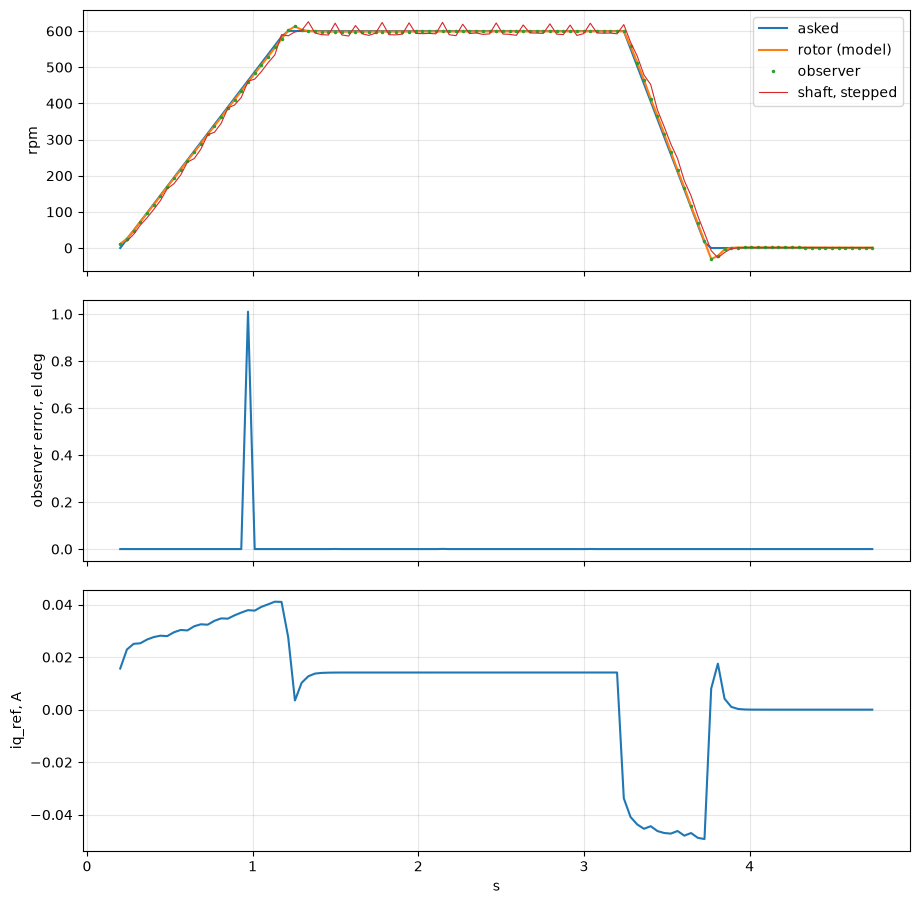

In [8]:
t = [r[0] for r in rows]
fig, (speed, error, current) = figure(rows=3, sharex=True)
speed.plot(t, [r[1] for r in rows], label='asked')
speed.plot(t, [r[2] for r in rows], label='rotor (model)')
speed.plot(t, [r[3] for r in rows], '.', markersize=3, label='observer')
speed.plot(t, [r[4] for r in rows], linewidth=0.8, label='shaft, stepped')
speed.set_ylabel('rpm')
speed.legend(loc='upper right')
error.plot(t, [r[5] for r in rows])
error.set_ylabel('observer error, el deg')
current.plot(t, [r[6] for r in rows])
current.set_ylabel('iq_ref, A')
current.set_xlabel('s')
show(fig)

## 6 The speed loop identified out of its own run

Blocks on one bus: a ramp, a d-axis probe (torque-free, and the one thing that lets Ld out of a fit), the speed loop, the current loop, the machine. `run` records every slot at every second PWM period; `identify` hands the run to `coaxial.model.sysid` and gets the constants back with an uncertainty per parameter. The machine is the stand-in's own, so every fit has a truth to be held against. The `velocity` verb defaults its `j` and `b` to this machine, the smallest plausible one, and the pair a bench motor really has is what this section finds.

In [9]:
from coaxial.control.loop import Ramp, Probe, SpeedLoop, CurrentLoop, Machine, identify
from coaxial.model.motor import BENCH_MOTOR
from coaxial.model import inverter

TWO_PI = 2.0 * math.pi
bench = BENCH_MOTOR
print(bench)
vdc = 24.0
chain = (Ramp(top=300.0 * TWO_PI, rise=0.6)
         >> Probe(amps=1.0, hz=40.0)
         >> SpeedLoop(hz=8.0, limit=6.0, motor=bench)
         >> CurrentLoop(hz=1000.0, motor=bench, vdc=vdc)
         >> Machine(bench, vdc=vdc, noise=0.02, sub=4))
run = chain.run(seconds=1.4, dt=2.0 * inverter.TS)
print('samples %d at %.0f us; top %.0f rad/s mechanical'
      % (len(run['t']), 2e6 * inverter.TS, run['w'].max()))

<stand-in bench motor ESTIMATED: R 0.0500 ohm, Ld 20.0 uH, Lq 30.0 uH, lambda 0.00500 Wb, 7 pole pairs, KV 158>


samples 35000 at 40 us; top 397 rad/s mechanical


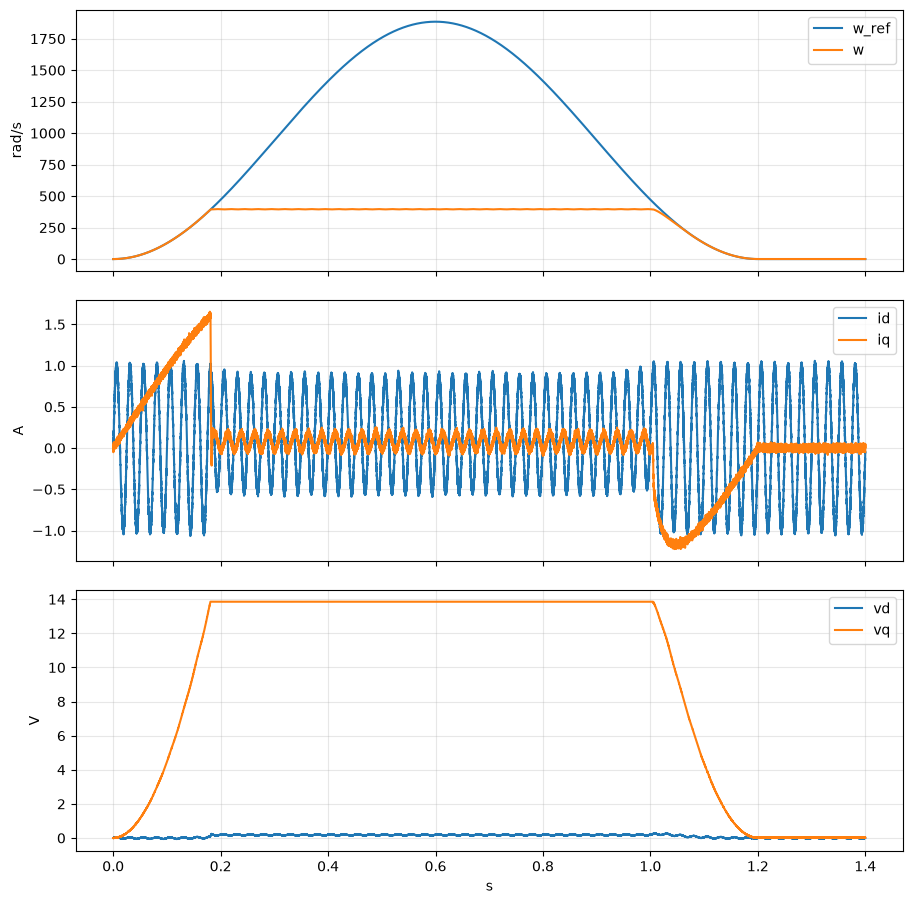

In [10]:
fig, (speed, current, voltage) = figure(rows=3, sharex=True)
speed.plot(run['t'], run['w_ref'], label='w_ref')
speed.plot(run['t'], run['w'], label='w')
speed.set_ylabel('rad/s')
speed.legend()
current.plot(run['t'], run['id'], label='id')
current.plot(run['t'], run['iq'], label='iq')
current.set_ylabel('A')
current.legend()
voltage.plot(run['t'], run['vd'], label='vd')
voltage.plot(run['t'], run['vq'], label='vq')
voltage.set_ylabel('V')
voltage.set_xlabel('s')
voltage.legend()
show(fig)

In [11]:
fit, got = identify(run, bench.poles)
print(fit)
print(fit.source)
print('condition %.2e  residual %.4f V' % (got['condition'], got['residual_v']))
TRUTH = (('r', bench.r), ('ld', bench.ld), ('lq', bench.lq), ('lam', bench.lam))
for name, truth in TRUTH:
    print('%-4s truth %.5g  fit %.5g  %+.1f %%  uncertainty %.1f %%  trusted %s'
          % (name, truth, got[name], 100.0 * (got[name] / truth - 1.0),
             100.0 * got['uncertainty'][name], got['trusted'][name]))

<identified ESTIMATED: R 0.0816 ohm, Ld 18.7 uH, Lq -2.7 uH, lambda 0.00500 Wb, 7 pole pairs, KV 158>
least squares over a simulated run - 35000 samples, condition 7.5e-01
condition 7.48e-01  residual 0.0990 V
r    truth 0.05  fit 0.08163  +63.3 %  uncertainty 0.8 %  trusted True
ld   truth 2e-05  fit 1.8732e-05  -6.3 %  uncertainty 2.3 %  trusted True
lq   truth 3e-05  fit -2.6631e-06  -108.9 %  uncertainty 21.4 %  trusted False
lam  truth 0.005  fit 0.004996  -0.1 %  uncertainty 0.0 %  trusted True


Without the probe the inductance column is R's: the same run, identified with `did/dt` unexcited.

In [12]:
still = (Ramp(top=300.0 * TWO_PI, rise=0.6)
         >> SpeedLoop(hz=8.0, limit=6.0, motor=bench)
         >> CurrentLoop(hz=1000.0, motor=bench, vdc=vdc)
         >> Machine(bench, vdc=vdc, noise=0.02, sub=4))
run2 = still.run(seconds=1.4, dt=2.0 * inverter.TS)
_, got2 = identify(run2, bench.poles)
for name, truth in TRUTH:
    print('%-4s fit %.5g  %+.1f %%  uncertainty %.1f %%  trusted %s'
          % (name, got2[name], 100.0 * (got2[name] / truth - 1.0),
             100.0 * got2['uncertainty'][name], got2['trusted'][name]))

r    fit 0.0046473  -90.7 %  uncertainty 24.1 %  trusted False
ld   fit 5.2515e-06  -73.7 %  uncertainty 24.4 %  trusted False
lq   fit -3.3285e-06  -111.1 %  uncertainty 17.4 %  trusted False
lam  fit 0.004997  -0.1 %  uncertainty 0.0 %  trusted True


## 7 The 5230SL and its propeller against the stand

`coaxial.model.motor` holds the Hobbywing Platinum 5230SL 190KV as the manufacturer's sheet gives it - poles and friction from the sheet, R, Ld, Lq and J estimated from the size class - and the APC20x10E fitted over the sheet's own 22-row thrust stand at 37 V. The chain is the last section's without the probe: a raised cosine to the stand's top row, 6717 rpm, and back, the propeller law on the machine as its load and in the speed loop as its feedforward, at the stand's 37 V. What the model makes at each of the stand's rpm is read against what the stand measured, and where the model stops short, the voltage says why.

In [13]:
from coaxial.model.motor import PLATINUM_5230SL, APC20x10E, APC20X10E_CURVE, RATINGS, KT_NM_PER_AMP

motor = PLATINUM_5230SL
print(motor)
print(motor.source)
print(APC20x10E, '-', APC20x10E.source)
print({k: RATINGS[k] for k in ('slots_poles', 'kv', 'i_max', 'p_max', 'source')})
print('Kt %.4f N.m/A' % KT_NM_PER_AMP)

<Hobbywing Platinum 5230SL 190KV ESTIMATED: R 0.0300 ohm, Ld 22.0 uH, Lq 29.0 uH, lambda 0.00207 Wb, 14 pole pairs, KV 190>
poles and friction from the manufacturer sheet (see RATINGS); R, Ld, Lq and J estimated from the size class - replace with an identification against the real machine
<APC20x10E: 5.143e-06 N.m/(rad/s)^2> - least squares over the 190KV sheet, 37 V, 25 C, sea level
{'slots_poles': '24N28P', 'kv': 190.0, 'i_max': 112.5, 'p_max': 4985.0, 'source': 'hobbywing.com Platinum 5220/5230 specification page'}
Kt 0.0435 N.m/A


In [14]:
import numpy as np

top = 6717.0 * TWO_PI / 60.0
sweep = (Ramp(top, rise=2.0)
         >> SpeedLoop(hz=4.0, limit=RATINGS['i_max'], motor=motor, load=APC20x10E)
         >> CurrentLoop(hz=800.0, motor=motor, vdc=37.0)
         >> Machine(motor, vdc=37.0, load=APC20x10E, noise=0.0, sub=4))
prop = sweep.run(seconds=4.5, dt=4.0 * inverter.TS, every=25)
rpm = prop['w'] * 60.0 / TWO_PI
torque = APC20x10E.k * prop['w'] ** 2
electrical = 1.5 * (prop['vd'] * prop['id'] + prop['vq'] * prop['iq'])
peak = int(rpm.argmax())
w_e = prop['w_e'][peak]
print('reached %.0f rpm, iq peak %.1f A, v_sat %.0f %% of the run'
      % (rpm.max(), abs(prop['iq']).max(), 100.0 * prop['v_sat'].mean()))
print('at the top: back-EMF %.1f V, omega Lq iq %.1f V, |v| %.1f of the %.1f V a sine gets from 37 V'
      % (w_e * motor.lam, w_e * motor.lq * prop['iq'][peak],
         math.hypot(prop['vd'][peak], prop['vq'][peak]), 37.0 / math.sqrt(3.0)))

reached 5696 rpm, iq peak 46.5 A, v_sat 22 % of the run
at the top: back-EMF 17.3 V, omega Lq iq 11.1 V, |v| 21.3 of the 21.4 V a sine gets from 37 V


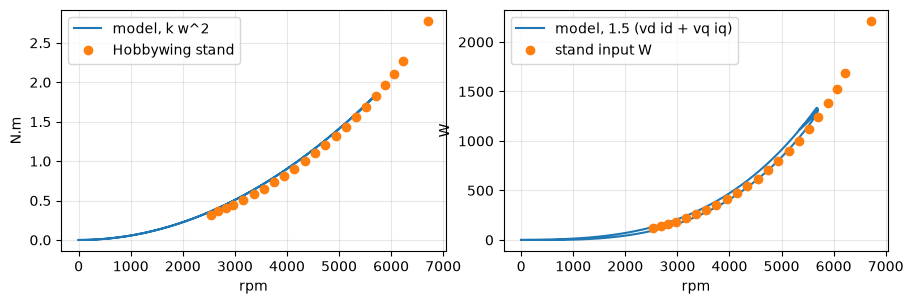

In [15]:
stand = np.array(APC20X10E_CURVE)
fig, (shaft, power) = figure(rows=1, cols=2)
shaft.plot(rpm, torque, label='model, k w^2')
shaft.plot(stand[:, 0], stand[:, 1], 'o', label='Hobbywing stand')
shaft.set_xlabel('rpm')
shaft.set_ylabel('N.m')
shaft.legend()
power.plot(rpm, electrical, label='model, 1.5 (vd id + vq iq)')
power.plot(stand[:, 0], stand[:, 2], 'o', label='stand input W')
power.set_xlabel('rpm')
power.set_ylabel('W')
power.legend()
show(fig)

In [16]:
print(' rpm    stand N.m   model N.m   stand W   model W')
for row_rpm, row_torque, row_watts in APC20X10E_CURVE[::4]:
    w = row_rpm * TWO_PI / 60.0
    near = np.argmin(np.abs(rpm[:peak] - row_rpm))
    print('%5d   %8.2f   %8.2f   %8.0f   %8.0f'
          % (row_rpm, row_torque, APC20x10E.k * w * w, row_watts, electrical[near]))
worst = 0.0
for row_rpm, row_torque, _watts in APC20X10E_CURVE:
    w = row_rpm * TWO_PI / 60.0
    worst = max(worst, abs(APC20x10E.k * w * w / row_torque - 1.0))
print('fit: k %.3e N.m/(rad/s)^2, worst row %.1f %% off a pure square' % (APC20x10E.k, 100.0 * worst))

 rpm    stand N.m   model N.m   stand W   model W
 2534       0.32       0.36        125        131
 3163       0.51       0.56        219        243
 3946       0.81       0.88        411        452
 4740       1.20       1.27        704        778
 5518       1.69       1.72       1118       1198
 6226       2.27       2.19       1684       1321
fit: k 5.143e-06 N.m/(rad/s)^2, worst row 13.2 % off a pure square


In [17]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 8 Conclusions

In [18]:
errs = [abs(r[5]) for r in rows]
rms = math.sqrt(sum(e * e for e in errs) / len(errs))
settled = [r for r in rows if abs(r[1] - 600.0) < 1.0 and r[4] == r[4]]
tach = [r[3] - r[4] for r in settled]
top_rpm = max(r[2] for r in rows)
top_row = APC20X10E_CURVE[-1]
print('1. stepper     ring %.2f deg peak to peak at about %.0f Hz after a 90 deg move, the spring says %.1f Hz;'
      % (max(ys) - min(ys), ring_hz, spring_hz))
print('               shaft %.2f deg from the detent against a command of 90.0; read at %.0f Hz'
      % (level, len(ring) / ring[-1][0]))
print('2. servo       no load: shaft %.2f deg, error %.2f; 0.02 N.m: sag %.2f deg measured, %.2f by the spring'
      % (landed, 45.0 - landed, sag, spring_sag))
print('               corrected: shaft %.2f deg, error %.2f, swing %.2f deg; holding torque 2.0 A x Kt %.4f = %.3f N.m'
      % (back, 45.0 - back, s.swing, kt, 2.0 * kt))
print('3. sensorless  %d passes at %.1f Hz; top %.0f rpm mechanical = %.0f rad/s electrical at %d pole pairs'
      % (len(rows), len(rows) / rows[-1][0], top_rpm, top_rpm * RAD_S_PER_RPM * poles, poles))
print('               observer error %.3f deg electrical rms, worst %.3f = %.4f deg mechanical; zero at constant speed'
      % (rms, max(errs), max(errs) / poles))
print('               observer minus shaft speed, settled: %+.1f rpm mean, %.1f rms over %d passes; at rest %.2f deg apart on the pole pitch'
      % (sum(tach) / len(tach), math.sqrt(sum(x * x for x in tach) / len(tach)), len(tach), offset))
print('4. identified  %-6s %-10s %-10s %-10s %s' % ('', 'truth', 'probe', 'no probe', 'probe -> none'))
for name, truth in TRUTH:
    print('               %-6s %-10.5g %-10.5g %-10.5g %+.1f %% -> %+.1f %%'
          % (name, truth, got[name], got2[name],
             100.0 * (got[name] / truth - 1.0), 100.0 * (got2[name] / truth - 1.0)))
print('               trusted with the probe %s, without %s; condition %.2e and %.2e'
      % ([n for n, _ in TRUTH if got['trusted'][n]], [n for n, _ in TRUTH if got2['trusted'][n]],
         got['condition'], got2['condition']))
print('5. propeller   k %.3e N.m/(rad/s)^2, worst row %.1f %% off a square; at %d rpm %.2f N.m needs %.1f A at Kt %.4f'
      % (APC20x10E.k, 100.0 * worst, top_row[0], top_row[1], top_row[1] / KT_NM_PER_AMP, KT_NM_PER_AMP))
print('               the model reached %.0f rpm at 37 V, iq peak %.1f A, v_sat %.0f %% of the run; the board %.0f A rated, the motor %.1f A burst'
      % (rpm.max(), abs(prop['iq']).max(), 100.0 * prop['v_sat'].mean(), 100.0, RATINGS['i_max']))
print('               lambda %.5f Wb from %d KV at %d pole pairs; Kt = 1.5 P lambda = %.4f N.m/A'
      % (motor.lam, RATINGS['kv'], motor.poles, 1.5 * motor.poles * motor.lam))

1. stepper     ring 0.09 deg peak to peak at about 30 Hz after a 90 deg move, the spring says 30.5 Hz;
               shaft 89.96 deg from the detent against a command of 90.0; read at 431 Hz
2. servo       no load: shaft 44.99 deg, error 0.01; 0.02 N.m: sag -1.56 deg measured, 1.57 by the spring
               corrected: shaft 44.99 deg, error 0.01, swing 2.11 deg; holding torque 2.0 A x Kt 0.0525 = 0.105 N.m
3. sensorless  113 passes at 23.8 Hz; top 613 rpm mechanical = 449 rad/s electrical at 7 pole pairs
               observer error 0.095 deg electrical rms, worst 1.010 = 0.1443 deg mechanical; zero at constant speed
               observer minus shaft speed, settled: +0.2 rpm mean, 13.0 rms over 51 passes; at rest -0.03 deg apart on the pole pitch
4. identified         truth      probe      no probe   probe -> none
               r      0.05       0.08163    0.0046473  +63.3 % -> -90.7 %
               ld     2e-05      1.8732e-05 5.2515e-06 -6.3 % -> -73.7 %
               lq   

Two verbs, one loop: `_slew_to` walks the command a quarter of a degree a write, so the spring never spans more than a few degrees at once, and the stepper's move and the servo's correction are that same code. `_energize` ramps the current instead of snapping it on: full current onto an unknown rotor is a yank of up to half a pole that an underdamped rotor rides through, pole after pole; grown slowly it detents into the nearest pole, and that is where angles count from. The ring is the spring: `sqrt(Kt I P / J)` on the record's Kt and the model's J lands on the trace's frequency, and with 2J/B at 4 s it has not died in the 0.6 s shown. The sag is the same spring: HOLD commutates on the commanded angle and the rotor sits where `amps Kt sin(delta)` balances the load, so `asin(T / I Kt) / P` is the number the trace lands on, and a stiffer hold is more current, not a tighter loop.

The servo closes **once per move**. The link corrects at tens of hertz and the load-angle spring rings at tens of hertz, so a per-pass loop samples its own resonance aliased and pumps it - six clean passes wound the rotor through a pole slip into a freewheel. Slew, let the ring die, read, correct. Every reading is a mean over the ring, never a read of it: nine reads 22 ms apart against a 28 Hz ring aliased to 17 Hz and left up to a degree of the ring in the answer, `to()` corrected it, the correction re-kicked the spring and the corrections pumped (+0.6, -1.0, +0.7) until `tries` ran out - the elbow of the robot arm mission, two runs in three, 2026-09-07 (FINDINGS). A shaft seen moving more than the slew's pitch is now read for a full second, some thirty periods of that ring, and `swing` says how far it moved. Arriving is two readings a settle apart, because a shaft being dragged past the target reads like one holding on it. `to()` raises after `tries` corrections still outside `tol` - a stalled arm is a fact, not a return code (invariant 8).

The observer estimates the **electrical** angle from the currents; the A1335 reads the **mechanical** shaft. They differ by the pole pairs, and an electrical degree of observer error is a fourteenth of a mechanical degree on the 5230SL - which is why an error that looks large in the estimate can be small at the shaft, and why the pole count has to come from the winding rather than from any torque measurement. The shaft sensor is absolute over one turn and needs a magnet; the observer needs neither, and holds down to the speed the back-EMF stops being readable against the dead-time residual - which is what `sensorless.crossover` computes and `drive.ipynb` measures. Below it the injection carries the estimate, and only saturation says which end of the d axis is the magnet. The stand-in's `theta_hat` is not the firmware's observer: it is a type-2 PLL lag at the record's own natural frequency, settling at `alpha / wn^2` - zero at constant speed, growing with acceleration, which is what the error trace shows; the firmware's is C, `tools/sim/observer_run.py` runs it and `test_drive_core.py` holds it to the Python it was ported from. One state read a pass carries both `omega_hat` and the fault: a trip here is a runaway or an overcurrent, the one place stopping the loop matters most, and taking it off the same reply costs no extra round trip. Two reads are two instants: at 600 rpm the shaft turns 3.6 degrees a millisecond, so angles are compared at rest and speeds on the way.

Two equations a sample, stacked; the columns are R, Ld, Lq and lambda, and each needs its own excitation. Without `did/dt` the inductance column is R's, which is why the probe is in the chain: torque-free, so the speed loop never sees it, and the one thing that lets Ld out of a fit. The per-parameter standard error says which column the run excited; one number for the whole fit does not. A V/f ramp once identified R to 0.4 %, Ld to 1.4 %, lambda to 0.1 % and **Lq to minus 73** - iq barely moved, so `Lq did/dt` had no excitation and `omega Lq iq` went collinear with lambda. The global condition was 6.5e-2 and said nothing. A trusted column is not a right one either: here R comes out 63 % high inside a 0.8 % error bar, and the same fit with the noise off reads the same 63 %, with the machine at ten sub-steps 30 %, at one period a loop 40 % - the bias is the simulated chain's discretisation, not the fit's noise, and a bench R is held against a meter before it is believed (invariant 7). Two alignment facts sit behind the numbers, both found by the fit reading wrong. The bus is published before the period advances, so the loops run one period behind the machine as the firmware's pipeline does; publishing after read R at +17 % and Lq at -4 %. And the vector is aimed half a period of angle ahead, being held in the stator frame while the rotor turns through it; without that R came out at -218 % of itself at 9000 rad/s. The pair matters to the third verb: an overstated `j` scales the speed loop's kp by the same factor and the discrete loop flips sign and doubles - measured, `j` five times the plant took +900 rpm asked to -1552 delivered - so `velocity` defaults to the smallest plausible machine and the real pair is identified, not assumed.

The sheet pins the **product** `Kt = 1.5 P lambda`, not the pole count: lambda from a KV goes as 1/P, so the P cancels and iq is the same whether the machine has 5 pole pairs or 14. No torque measurement gives P; it came from the winding, 24N28P being 28 poles and 14 pairs, and the observer needs it on its own because electrical speed is P times mechanical. `b` is arithmetic off the sheet: 3.0 A at 44.4 V spins it at 8436 rpm, so 133 W against 883 rad/s is 0.151 N.m of drag. R, Ld, Lq and J come from the size class; `commissioning.ipynb` replaces them. Two ratings bound the drive: the motor's 112.5 A burst sits above the board's 100 A, so the **inverter** is the limit, and a 12S pack at full charge is 50.4 V against a 63 V rating and 78.15 V of divider scale (invariant 11). The model meets the stand at the stand's rpm because `k` was fitted over those 22 rows; the curve is kept whole in `APC20X10E_CURVE` so the fit can be re-done. Where the model stops short of the top row it is out of voltage, not current: at 46 A the size-class Lq drops 11 V of the 21.4 V a sine gets from 37 V, and the stand reached 6717 rpm on that same link - the inductance is the first number an identification of the real machine replaces.

**At the bench.** Flip `SIMULATED` and name the port; the stage arms for real, so the STO chain must have released the drivers' supply and `bypass_sto` is a decision, not a default. Run the stepper first: it needs no sensor, and the ring's frequency against `sqrt(Kt I P / J)` is the first number the real J gives - the stand-in's 2e-5 is invented. The servo needs the A1335 seeing a magnet (`sensors.ipynb`); compare the sag against the spring's arithmetic, since a sag larger than it is a Kt smaller than the record's. The velocity verb needs a commissioned record (`commissioning.ipynb` writes it); the observer-against-shaft speeds are the real comparison there, because the stand-in's observer is a lag and the firmware's is not, and `tach` at a link's 15 ms read pace is coarser than here. For the identification the run comes off `daq.frame` through `sysid.from_frame` rather than a chain, and R is checked against a meter before the record takes it. The propeller section is the sheet's arithmetic and needs a thrust stand to become more; nothing here has run near 63 V or 100 A. The stand-in could not show a pole slipped under a real load, a trace read at 2 ms over a link, or the firmware observer's own floor.

## References

* `host/coaxial/control/motion.py` - the three verbs: the slew, the soft energize, the ring-aware measurement, the fault read a pass
* `host/coaxial/control/loop.py` - the blocks on one bus: ramp, probe, speed loop, current loop, machine, and `identify`
* `host/coaxial/model/sysid.py` - the least squares behind `identify`: two equations a sample, an error bar per column
* `host/coaxial/model/motor.py` - the 5230SL as the sheet gives it, the propeller and its 22-row curve, `Kt = 1.5 P lambda`
* `host/coaxial/simulated/drive/` - the stand-in's rotor, the spring under HOLD, and the PLL lag that stands in for the observer
* `host/tests/test_sensorless.py` - the verbs pinned on the stand-in, the dangerous paths included: a load past the holding torque, a trip mid-spin
* `host/tools/sim/observer_run.py` - the firmware's own observer, run on the host, and the crossover it computes
* `docs/FINDINGS.md` - the motion verbs, 2026-09-07: the aliased ring, the pumped corrections, the rotor's integrator